# PyEncode — Paper Experiments

Reproduces all examples and gate-count comparisons from the paper.
Uses the three entry points: `encode_params`, `encode_vector`, `encode_python`.

## 1. Imports and Configuration

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from qiskit import transpile, QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import StatePreparation
import qiskit

from pyencode import (
    encode_params, encode_vector, encode_python,
    EncodingInfo, VectorType,
    DISCRETE, UNIFORM, STEP, SQUARE,
    SINE, COSINE, MULTI_DISCRETE, MULTI_SINE,
)

N = 64
m = 6
from pyencode.config import BASIS_GATES as BASIS, OPTIMIZATION_LEVEL, DECOMPOSE_REPS
k = np.arange(N)
print(f'N = {N}, m = {m} qubits')
print(f"Qiskit version: {qiskit.__version__}")

N = 64, m = 6 qubits
Qiskit version: 2.3.0


## 2. Helper Functions

In [2]:
def plot_vector(f, title, smooth=False):
    """Plot a vector with bar or smooth style."""
    fig, ax = plt.subplots(figsize=(6, 2.5))
    x = np.arange(len(f))
    if smooth:
        from scipy.interpolate import make_interp_spline
        xs = np.linspace(0, len(f)-1, 500)
        spl = make_interp_spline(x, f, k=3)
        ax.plot(xs, spl(xs), 'steelblue', lw=1.5)
        ax.fill_between(xs, 0, spl(xs), alpha=0.15, color='steelblue')
        ax.plot(x, f, 'o', color='steelblue', ms=2, alpha=0.4)
    else:
        ax.bar(x, f, width=1.0, color='steelblue', edgecolor='steelblue', lw=0.3)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlabel('Node index $i$'); ax.set_ylabel('$f_i$')
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-0.5, len(f)-0.5)
    plt.tight_layout(); plt.show()

def verify_circuit(circuit, info, label=''):
    """Verify circuit against the vector implied by info.params."""
    from pyencode._helpers import _build_expected_vector
    from pyencode.recognizer import LoadPattern, VectorType
    pattern = LoadPattern(VectorType[info.vector_type], N=info.N, params=info.params)
    expected_f = _build_expected_vector(pattern, fallback_vector=None)
    if expected_f is None:
        print(f'  {label} verification: SKIP (no expected vector)')
        return
    sv = np.abs(np.array(Statevector(circuit)))
    ref = np.abs(expected_f / np.linalg.norm(expected_f))
    err = np.max(np.abs(sv - ref))
    status = 'PASS' if err < 1e-5 else f'FAIL (err={err:.2e})'
    print(f'  {label} verification: {status}')

def qiskit_gates(f_vec):
    """Gate count for Shende StatePreparation on a vector."""
    sv = f_vec / np.linalg.norm(f_vec)
    qc = QuantumCircuit(m)
    qc.append(StatePreparation(sv.astype(float)), range(m))
    qc = qc.decompose(reps=DECOMPOSE_REPS)
    t = transpile(qc, basis_gates=BASIS, optimization_level=OPTIMIZATION_LEVEL)
    return sum(t.count_ops().values())

def qiskit_circuit(f_vec):
    """Quantum circuit Shende StatePreparation on a vector."""
    sv = f_vec / np.linalg.norm(f_vec)
    qc = QuantumCircuit(m)
    qc.append(StatePreparation(sv.astype(float)), range(m))
    qc = qc.decompose(reps=DECOMPOSE_REPS)
    t = transpile(qc, basis_gates=BASIS, optimization_level=OPTIMIZATION_LEVEL)
    return t

---
## 3. All Vector Types

### 3.1 Discrete — $f_i = P\,\delta_{ik}$ — $\mathcal{O}(m)$

PyEncode  v0.4.0
  Vector type : DISCRETE
  N           : 64  (m = 6 qubits)
  Gate count  : 2
  Complexity  : O(m)
  Validated   : no
  Parameters  : {'k': 24, 'P': 1.0}
  DISCRETE verification: PASS
Qiskit gate count: 10


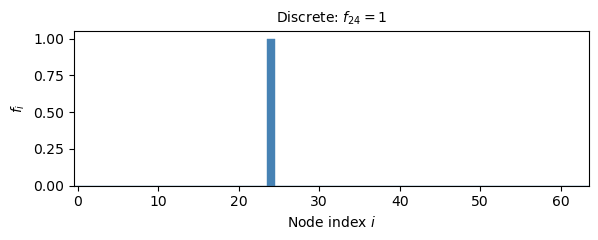

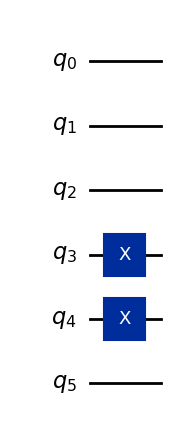

In [3]:
# encode_params
index = 24
circuit, info = encode_params(DISCRETE(k=index, P=1.0), N=N)
print(info)

f = np.zeros(N); f[index] = 1.0
verify_circuit(circuit, info, 'DISCRETE')
print(f'Qiskit gate count: {qiskit_gates(f)}')
plot_vector(f, f'Discrete: $f_{{{index}}}=1$')

circuit.draw('mpl')


## Plot gate count as a function Discrete index

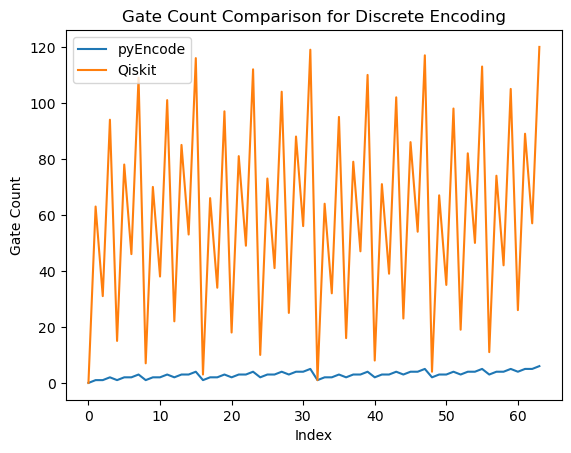

In [4]:
# encode_params
pyencode_list = []
qiskit_list = []
for index in range(N):
    circuit, info = encode_params(DISCRETE(k=index, P=1.0), N=N)
    pyEncode_gates = info.gate_count
    f = np.zeros(N); f[index] = 1.0
    #verify_circuit(circuit, info, 'DISCRETE')
    qiskit_gatecount = qiskit_gates(f)
    pyencode_list.append(pyEncode_gates)
    qiskit_list.append(qiskit_gatecount)
    
    
plt.plot(pyencode_list, label='pyEncode')
plt.plot(qiskit_list, label='Qiskit')    
plt.xlabel('Index')
plt.ylabel('Gate Count')
plt.title('Gate Count Comparison for Discrete Encoding')
plt.legend()



## Bug?
## Return FAIL

In [5]:
# encode_python (AST path, no hint)
code = """
N = 64
f = np.zeros(N)
f[3] = 1.0
"""
f = np.zeros(N); f[3] = 1.0          # ← must match what the code encodes
circuit2, info2 = encode_python(code)
print(f'encode_python: {info2.vector_type}, gates={info2.gate_count}')
verify_circuit(circuit2, info2, 'encode_python')

encode_python: DISCRETE, gates=2
  encode_python verification: PASS


In [6]:
# encode_vector (auto-detect)
circuit3, info3 = encode_vector(f)
print(f'encode_vector: {info3.vector_type}, gates={info3.gate_count}')
verify_circuit(circuit3, info3, 'encode_vector')

encode_vector: DISCRETE, gates=2
  encode_vector verification: PASS


### Bug?
## Example from Gleinig et. al An Efficient Algorithm for Sparse Quantum State Preparation

In [7]:
m2 = 20
N2 = 2**m2
circuit, info = encode_params(
    MULTI_DISCRETE(vectors=[DISCRETE(k=1, P=2.0), DISCRETE(k=4, P=8.0), DISCRETE(k=7, P=10.0)]),
    N=N2,
)
print(info)

# Gleinig et. al achieve a gate count of 70 gates  




PyEncode  v0.4.0
  Vector type : MULTI_DISCRETE
  N           : 1048576  (m = 20 qubits)
  Gate count  : 8
  Complexity  : O(m · L)
  Validated   : no
  Parameters  : {'loads': [{'k': 1, 'P': 2.0}, {'k': 4, 'P': 8.0}, {'k': 7, 'P': 10.0}]}


### 3.2 Uniform — $f_i = c$ — $\mathcal{O}(m)$

PyEncode  v0.4.0
  Vector type : UNIFORM
  N           : 64  (m = 6 qubits)
  Gate count  : 6
  Complexity  : O(m)
  Validated   : no
  Parameters  : {'c': 2.0}
Qiskit gate count: 6


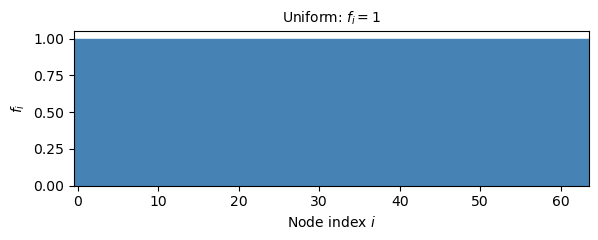

  UNIFORM verification: PASS


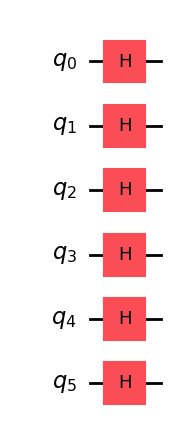

In [8]:
circuit, info = encode_params(UNIFORM(c=2.0), N=N)
print(info)

f = np.full(N, 1.0)
print(f'Qiskit gate count: {qiskit_gates(f)}')
plot_vector(f, 'Uniform: $f_i=1$')
verify_circuit(circuit, info, 'UNIFORM')
circuit.draw('mpl')

In [9]:
# encode_python
circuit2, info2 = encode_python(f"N = {N}\nf = np.ones(N) * 2.0")
print(f'encode_python: {info2.vector_type}, gates={info2.gate_count}')

encode_python: UNIFORM, gates=6


### 3.3 Step — $f_i = c\,\mathbf{1}[i < k_s]$ — $\mathcal{O}(m)$

PyEncode  v0.4.0
  Vector type : STEP
  N           : 64  (m = 6 qubits)
  Gate count  : 2
  Complexity  : O(m)
  Validated   : no
  Parameters  : {'k_s': 4, 'c': 1.0}


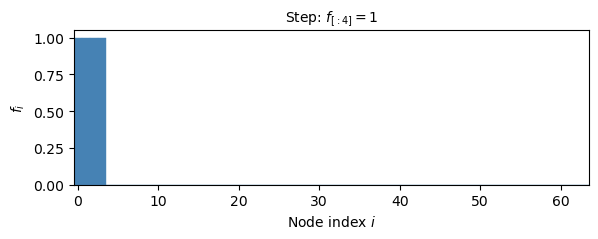

  STEP verification: PASS


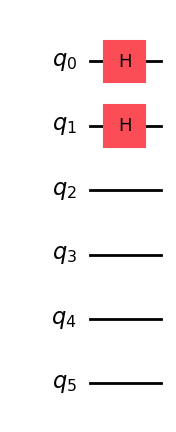

In [10]:
circuit, info = encode_params(STEP(k_s=4, c=1.0), N=N)
print(info)

f = np.zeros(N); f[:4] = 1.0
plot_vector(f, 'Step: $f_{[:4]}=1$')
verify_circuit(circuit, info, 'STEP')
circuit.draw('mpl')

In [11]:
# encode_vector auto-detect
circuit2, info2 = encode_vector(f)
print(f'encode_vector: {info2.vector_type}, gates={info2.gate_count}')

encode_vector: STEP, gates=2


### 3.4 Square — $f_i = c\,\mathbf{1}[k_1 \leq i < k_2]$ — $\mathcal{O}(m)$

PyEncode  v0.4.0
  Vector type : SQUARE
  N           : 64  (m = 6 qubits)
  Gate count  : 4
  Complexity  : O(m)
  Validated   : no
  Parameters  : {'k1': 8, 'k2': 16, 'c': 1.0}


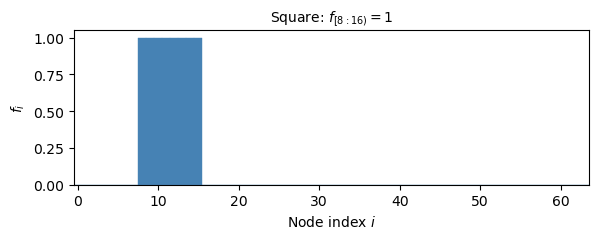

  SQUARE verification: PASS


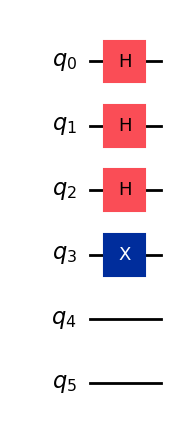

In [12]:
circuit, info = encode_params(SQUARE(k1=8, k2=16, c=1.0), N=N)
print(info)

f = np.zeros(N); f[8:16] = 1.0
plot_vector(f, 'Square: $f_{[8:16)}=1$')
verify_circuit(circuit, info, 'SQUARE')
circuit.draw('mpl')

### 3.5 Sine — $f_i = A\sin(2\pi n i/N + \varphi)$ — $\mathcal{O}(m^2)$

PyEncode  v0.4.0
  Vector type : SINE
  N           : 64  (m = 6 qubits)
  Gate count  : 11
  Complexity  : O(m²)
  Validated   : no
  Parameters  : {'n': 1, 'A': 1.0, 'phi': 0.0}


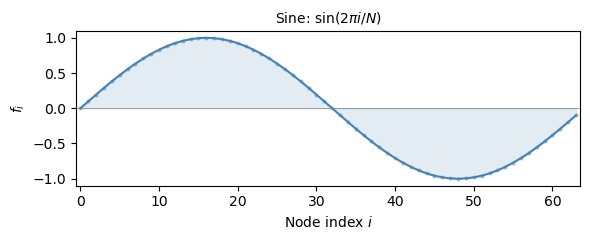

  SINE n=1 verification: PASS


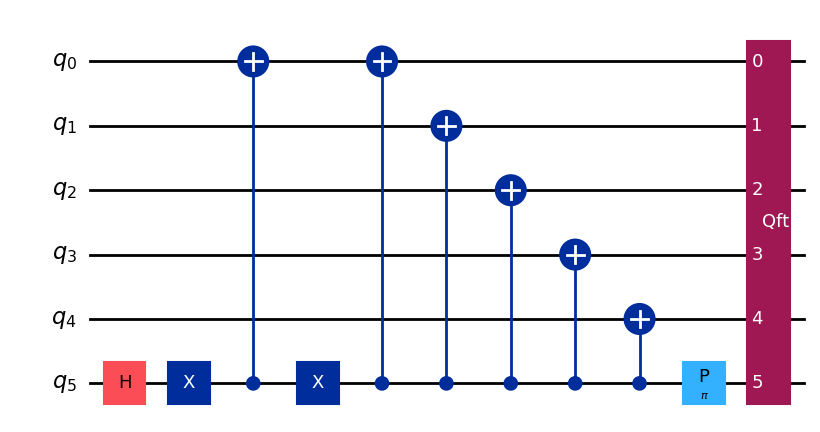

In [13]:
# n=1, no phase
circuit, info = encode_params(SINE(n=1, A=1.0), N=N)
print(info)

f = np.sin(2 * np.pi * 1 * k / N)
plot_vector(f, r'Sine: $\sin(2\pi i/N)$', smooth=True)
verify_circuit(circuit, info, 'SINE n=1')
circuit.draw('mpl')

PyEncode  v0.4.0
  Vector type : SINE
  N           : 64  (m = 6 qubits)
  Gate count  : 13
  Complexity  : O(m²)
  Validated   : no
  Parameters  : {'n': 3, 'A': 2.0, 'phi': 0.7853981633974483}


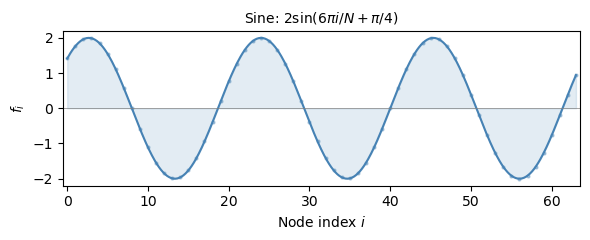

  SINE n=3 phi=pi/4 verification: PASS


In [14]:
# n=3, phi=pi/4
circuit, info = encode_params(SINE(n=3, A=2.0, phi=np.pi/4), N=N)
print(info)

f = 2.0 * np.sin(2 * np.pi * 3 * k / N + np.pi/4)
plot_vector(f, r'Sine: $2\sin(6\pi i/N + \pi/4)$', smooth=True)
verify_circuit(circuit, info, 'SINE n=3 phi=pi/4')

In [15]:
# encode_python with hint (for-loop syntax)
code = f"""
import numpy as np
N = {N}
f = np.zeros(N)
for i in range(N):
    f[i] = np.sin(2 * np.pi * i / N)
"""
circuit2, info2 = encode_python(code, vector_type='SINE')
print(f'encode_python (loop+hint): {info2.vector_type}, n={info2.params["n"]}')

encode_python (loop+hint): SINE, n=1


### 3.6 Cosine — $f_i = A\cos(2\pi n i/N + \varphi)$ — $\mathcal{O}(m^2)$

PyEncode  v0.4.0
  Vector type : COSINE
  N           : 64  (m = 6 qubits)
  Gate count  : 11
  Complexity  : O(m²)
  Validated   : no
  Parameters  : {'n': 1, 'A': 1.0, 'phi': 0.0}


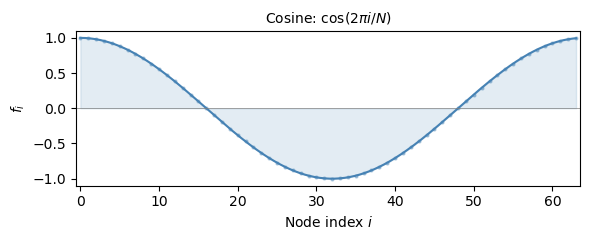

  COSINE n=1 verification: PASS


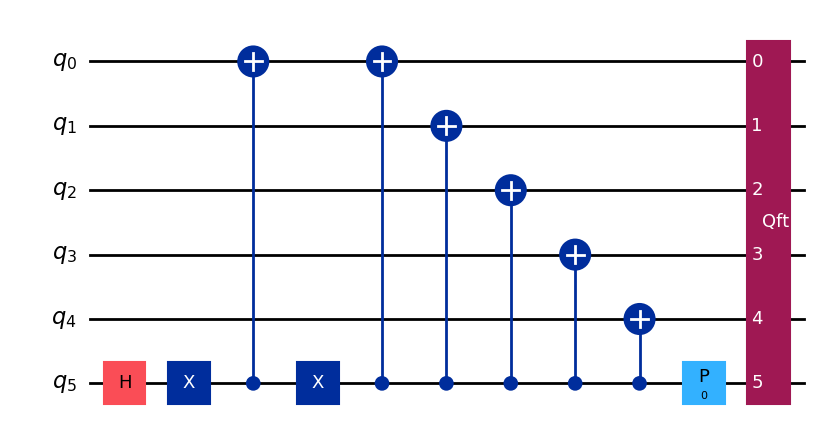

In [16]:
circuit, info = encode_params(COSINE(n=1, A=1.0), N=N)
print(info)

f = np.cos(2 * np.pi * 1 * k / N)
plot_vector(f, r'Cosine: $\cos(2\pi i/N)$', smooth=True)
verify_circuit(circuit, info, 'COSINE n=1')
circuit.draw('mpl')

PyEncode  v0.4.0
  Vector type : COSINE
  N           : 64  (m = 6 qubits)
  Gate count  : 13
  Complexity  : O(m²)
  Validated   : no
  Parameters  : {'n': 3, 'A': 1.0, 'phi': 0.7853981633974483}


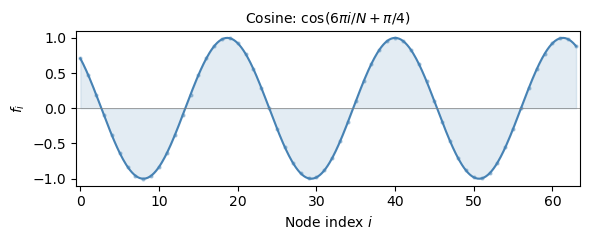

  COSINE n=3 phi=pi/4 verification: PASS


In [17]:
# n=3, phi=pi/4
circuit, info = encode_params(COSINE(n=3, A=1.0, phi=np.pi/4), N=N)
print(info)

f = np.cos(2 * np.pi * 3 * k / N + np.pi/4)
plot_vector(f, r'Cosine: $\cos(6\pi i/N + \pi/4)$', smooth=True)
verify_circuit(circuit, info, 'COSINE n=3 phi=pi/4')

### 3.7 Multi-Discrete — $f_i = \sum_j P_j\,\delta_{i,k_j}$ — $\mathcal{O}(|S|\,m)$

PyEncode  v0.4.0
  Vector type : MULTI_DISCRETE
  N           : 64  (m = 6 qubits)
  Gate count  : 6
  Complexity  : O(m · L)
  Validated   : no
  Parameters  : {'loads': [{'k': 10, 'P': 3.0}, {'k': 50, 'P': 4.0}]}


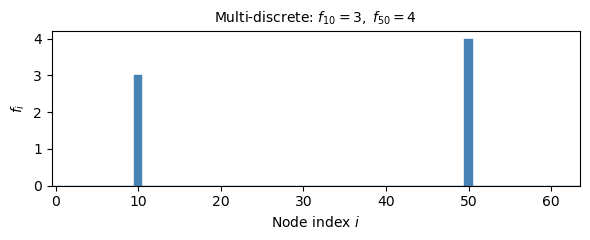

  MULTI_DISCRETE L=2 verification: PASS


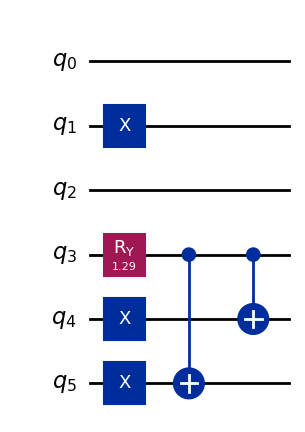

In [18]:
# Two point loads
circuit, info = encode_params(
    MULTI_DISCRETE(vectors=[DISCRETE(k=10, P=3.0), DISCRETE(k=50, P=4.0)]),
    N=N,
)
print(info)

f = np.zeros(N); f[10] = 3.0; f[50] = 4.0
plot_vector(f, 'Multi-discrete: $f_{10}=3,\;f_{50}=4$')
verify_circuit(circuit, info, 'MULTI_DISCRETE L=2')
circuit.draw('mpl')

L=4: gates=16


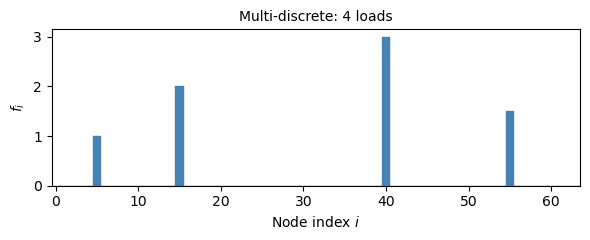

  MULTI_DISCRETE L=4 verification: PASS


In [19]:
# Four point loads
circuit, info = encode_params(
    MULTI_DISCRETE(vectors=[
        DISCRETE(k=5, P=1.0), DISCRETE(k=15, P=2.0),
        DISCRETE(k=40, P=3.0), DISCRETE(k=55, P=1.5),
    ]),
    N=N,
)
print(f'L=4: gates={info.gate_count}')

f = np.zeros(N); f[5]=1; f[15]=2; f[40]=3; f[55]=1.5
plot_vector(f, 'Multi-discrete: 4 loads')
verify_circuit(circuit, info, 'MULTI_DISCRETE L=4')

In [20]:
# encode_vector auto-detect
f = np.zeros(N); f[10] = 3.0; f[50] = 4.0
circuit2, info2 = encode_vector(f)
print(f'encode_vector: {info2.vector_type}, gates={info2.gate_count}')

encode_vector: MULTI_DISCRETE, gates=6


### 3.8 Multi-Sine — $f_i = \sum_t A_t \sin(2\pi n_t i/N)$ — $\mathcal{O}(m^2)$

PyEncode  v0.4.0
  Vector type : MULTI_SINE
  N           : 64  (m = 6 qubits)
  Gate count  : 10
  Complexity  : O(m²)
  Validated   : no
  Parameters  : {'modes': [{'n': 1, 'A': 2.0}, {'n': 3, 'A': 1.0}]}


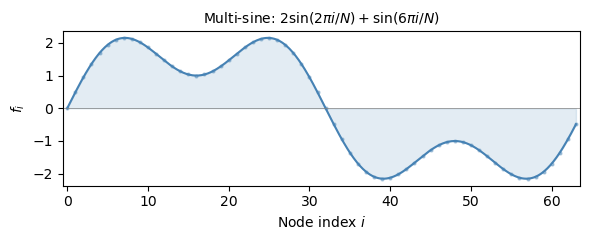

  MULTI_SINE verification: PASS


In [21]:
circuit, info = encode_params(
    MULTI_SINE(modes=[SINE(n=1, A=2.0), SINE(n=3, A=1.0)]),
    N=N,
)
print(info)

f = 2.0 * np.sin(2*np.pi*1*k/N) + np.sin(2*np.pi*3*k/N)
plot_vector(f, r'Multi-sine: $2\sin(2\pi i/N) + \sin(6\pi i/N)$', smooth=True)
verify_circuit(circuit, info, 'MULTI_SINE')

### 3.9 Shende Fallback — unrecognised pattern


Type: UNKNOWN, complexity: O(2^m), gates: 1


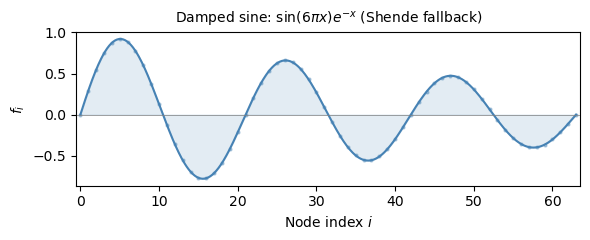

In [22]:
# Damped sine: not in the pattern library
code = f"""
import numpy as np
N = {N}
x = np.linspace(0, 1, N)
f = np.sin(3 * 2*np.pi * x) * np.exp(-x)
"""

with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always')
    circuit, info = encode_python(code)
    if w:
        print(f'Warning: {w[0].message}')

print(f'\nType: {info.vector_type}, complexity: {info.complexity}, gates: {info.gate_count}')

f = np.sin(3 * 2*np.pi * np.linspace(0,1,N)) * np.exp(-np.linspace(0,1,N))
plot_vector(f, r'Damped sine: $\sin(6\pi x)e^{-x}$ (Shende fallback)', smooth=True)

In [23]:
# Random vector
rng = np.random.default_rng(42)
f_rand = rng.standard_normal(N)

try:
    encode_vector(f_rand)
except ValueError as e:
    print(f'Auto-detect fails: {e}')

Auto-detect fails: No known load type matches the vector.  Use encode_vector(f, vector_type=...) with an explicit type.


---
## 4. Gate Count Comparison (Table 3)

Reproduces Table 3 from the paper: PyEncode (raw + transpiled) vs Shende, N=64.

In [24]:
def pyencode_counts(vobj):
    c, info = encode_params(vobj, N=N)
    raw = info.gate_count
    t = transpile(c, basis_gates=BASIS, optimization_level=OPTIMIZATION_LEVEL)
    transp = sum(t.count_ops().values())
    return raw, transp, info.complexity

cases = [
    ('Discrete (k=20)',       DISCRETE(k=20, P=1.0),        np.eye(N)[20]),
    ('Uniform',               UNIFORM(c=1.0),               np.ones(N)),
    ('Step (k_s=4)',          STEP(k_s=4, c=1.0),           np.array([1 if i<4 else 0 for i in range(N)], dtype=float)),
    ('Square ([8,16))',       SQUARE(k1=8, k2=16, c=1.0),   np.array([1 if 8<=i<16 else 0 for i in range(N)], dtype=float)),
    ('Sin (n=1, phi=0)',      SINE(n=1, A=1.0),             np.sin(2*np.pi*1*k/N)),
    ('Sin (n=3, phi=pi/4)',   SINE(n=3, A=2.0, phi=np.pi/4), 2*np.sin(2*np.pi*3*k/N+np.pi/4)),
    ('Cos (n=1, phi=0)',      COSINE(n=1, A=1.0),           np.cos(2*np.pi*1*k/N)),
    ('Cos (n=3, phi=pi/4)',   COSINE(n=3, A=1.0, phi=np.pi/4), np.cos(2*np.pi*3*k/N+np.pi/4)),
    ('Multi-discrete (|S|=2)', MULTI_DISCRETE(vectors=[DISCRETE(k=10,P=3.0), DISCRETE(k=50,P=4.0)]),
     np.array([3 if i==10 else 4 if i==50 else 0 for i in range(N)], dtype=float)),
]

print(f'{"Pattern":<28} {"Raw":>5} {"Trans":>6} {"O(.)":<10} {"Shende":>7}')
print('-' * 62)
for name, vobj, f_vec in cases:
    raw, transp, compl = pyencode_counts(vobj)
    sg = qiskit_gates(f_vec)
    print(f'{name:<28} {raw:>5} {transp:>6} {compl:<10} {sg:>7}')

Pattern                        Raw  Trans O(.)        Shende
--------------------------------------------------------------
Discrete (k=20)                  2      2 O(m)            18
Uniform                          6      6 O(m)             6
Step (k_s=4)                     2      2 O(m)            62
Square ([8,16))                  4      4 O(m)            52
Sin (n=1, phi=0)                11     73 O(m²)          119
Sin (n=3, phi=pi/4)             13     75 O(m²)          119
Cos (n=1, phi=0)                11     73 O(m²)          120
Cos (n=3, phi=pi/4)             13     75 O(m²)          118
Multi-discrete (|S|=2)           6      6 O(m · L)        42


---
## 5. Application Examples

### 5.1 Quantum Chemistry: Fermi-Hubbard PREP

PyEncode  v0.4.0
  Vector type : COMPOSITE
  N           : 32  (m = 5 qubits)
  Gate count  : 53
  Complexity  : O(2 * component)
  Validated   : no
  Parameters  : {'components': ['SQUARE', 'SQUARE']}


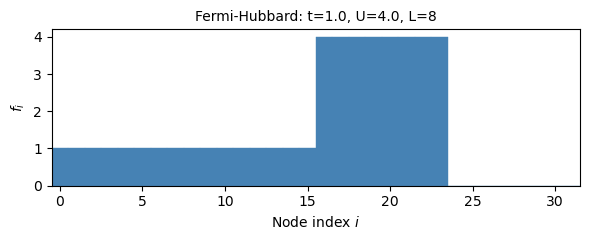

In [25]:
L = 8; t_hop = 1.0; U_int = 4.0
N_pauli = 4 * L  # = 32

circuit, info = encode_params([
    SQUARE(k1=0, k2=2*L, c=t_hop),
    SQUARE(k1=2*L, k2=3*L, c=U_int),
], N=N_pauli)
print(info)

f = np.zeros(N_pauli); f[0:2*L] = t_hop; f[2*L:3*L] = U_int
plot_vector(f, f'Fermi-Hubbard: t={t_hop}, U={U_int}, L={L}')

### 5.2 Computational Mechanics: 2D Poisson

x-register: 9 gates
y-register: 12 gates
Total: 21 gates for 1024 amplitudes


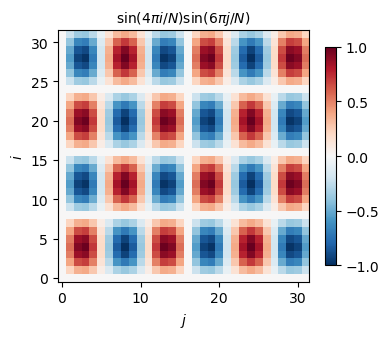

In [26]:
N_grid = 32
k_grid = np.arange(N_grid)

circ_x, info_x = encode_params(SINE(n=2, A=1.0), N=N_grid)
circ_y, info_y = encode_params(SINE(n=3, A=1.0), N=N_grid)
circuit = circ_x.tensor(circ_y)

print(f'x-register: {info_x.gate_count} gates')
print(f'y-register: {info_y.gate_count} gates')
print(f'Total: {info_x.gate_count + info_y.gate_count} gates for {N_grid**2} amplitudes')

u = np.sin(2*np.pi*2*k_grid/N_grid)
v = np.sin(2*np.pi*3*k_grid/N_grid)
f_2d = np.outer(u, v)

fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(f_2d, origin='lower', cmap='RdBu_r', aspect='equal')
ax.set_xlabel('$j$'); ax.set_ylabel('$i$')
ax.set_title(r'$\sin(4\pi i/N)\sin(6\pi j/N)$', fontsize=10)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

### 5.3 Quantum Finance: Price Distribution

PyEncode  v0.4.0
  Vector type : MULTI_DISCRETE
  N           : 64  (m = 6 qubits)
  Gate count  : 28
  Complexity  : O(m · L)
  Validated   : no
  Parameters  : {'loads': [{'k': 8, 'P': 0.05}, {'k': 16, 'P': 0.15}, {'k': 24, 'P': 0.25}, {'k': 32, 'P': 0.3}, {'k': 40, 'P': 0.15}, {'k': 48, 'P': 0.07}, {'k': 56, 'P': 0.03}]}


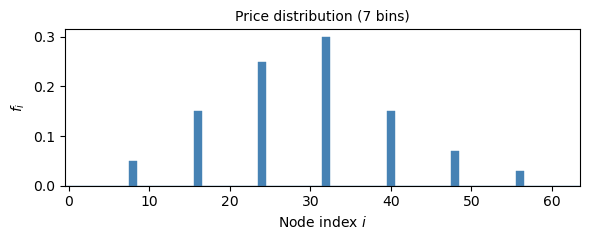


PyEncode: 28 gates
Shende:   11 gates


In [27]:
indices = [8, 16, 24, 32, 40, 48, 56]
weights = [0.05, 0.15, 0.25, 0.30, 0.15, 0.07, 0.03]

circuit, info = encode_params(
    MULTI_DISCRETE(vectors=[
        DISCRETE(k=k_i, P=w_i)
        for k_i, w_i in zip(indices, weights)
    ]),
    N=N,
)
print(info)

f = np.zeros(N)
for k_i, w_i in zip(indices, weights):
    f[k_i] = w_i
plot_vector(f, 'Price distribution (7 bins)')

print(f'\nPyEncode: {info.gate_count} gates')
print(f'Shende:   {qiskit_gates(f)} gates')

---
## 6. Circuit Code Output

Every call returns a standalone Qiskit script in `info.circuit_code`.

In [28]:
_, info = encode_params(SINE(n=1, A=1.0), N=16)
print(info.circuit_code)

# PyEncode — emitted circuit: SINUSOIDAL_LOAD  n=1  phi=0.0000
# m = 4 qubits,  N = 16 nodes
# Edit freely; run as standalone Qiskit code.

from qiskit import QuantumCircuit

import math
from qiskit.circuit.library import QFTGate

m, N, n, phi = 4, 16, 1, 0.0

qc = QuantumCircuit(m, name='sin_n1_phi0.0000')

# ── Step 1: prepare frequency-domain state ────────────────────────
# Target: (e^{i*phi}|1> - e^{-i*phi}|15>) / sqrt(2)
# Hadamard on MSB creates two branches: |0>|...> and |1>|...>
qc.h(m - 1)  # qubit 3: root of the two branches

# Branch |0> on qubit 3: encode index n=1 on lower qubits
qc.x(m - 1)          # temporarily flip control to make CX active
qc.cx(m - 1, 0)  # set bit 0 of index 1
qc.x(m - 1)          # restore

# Branch |1> on qubit 3: encode index N-n=15 on lower qubits
qc.cx(m - 1, 0)  # set bit 0 of index 15
qc.cx(m - 1, 1)  # set bit 1 of index 15
qc.cx(m - 1, 2)  # set bit 2 of index 15

# ── Step 2: relative phase gate ───────────────────────────────────
# P(pi 